In [3]:
import os
import glob
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# 1. PENCARIAN FILE DI BERBAGAI LOKASI POTENSIAL
# =========================================================
search_paths = [
    "/home/math_sutarman/Rina_paper",      # Path absolut yang Anda sebutkan
    "/home/math_sutarman/rina_paper",      # Variasi huruf kecil
    os.getcwd(),                           # Direktori kerja Jupyter saat ini
    "."                                    # Direktori saat ini
]

found_files = []
extensions = ['*.csv', '*.xlsx', '*.xls', '*.parquet']

print("="*80)
print("MEMINDAI SEMUA FILE DATASET DI FOLDER KERJA...")
print("="*80)

for base_path in search_paths:
    if os.path.exists(base_path):
        for ext in extensions:
            # Cari secara rekursif di dalam folder
            files = glob.glob(os.path.join(base_path, "**", ext), recursive=True)
            for f in files:
                # Hindari file temporary atau hidden
                if not os.path.basename(f).startswith('.') and not os.path.basename(f).startswith('~'):
                    found_files.append(f)
        
        if found_files:
            print(f"[SUCCESS] Ditemukan file di sekitar: {base_path}")
            break
    else:
        print(f"[INFO] Path tidak ditemukan: {base_path}")

# Hapus duplikat dan urutkan
found_files = sorted(list(set(found_files)))

if not found_files:
    print("\n[WARNING] Tidak ada file data (.csv, .xlsx, .parquet) yang ditemukan.")
    print("Pastikan file dataset sudah diunggah ke folder kerja Jupyter Anda atau path sudah benar.")
else:
    print(f"\n[DITEMUKAN] {len(found_files)} file data potensial:")
    for i, f in enumerate(found_files):
        size_mb = os.path.getsize(f) / (1024 * 1024)
        print(f"[{i+1}] {os.path.basename(f)} ({size_mb:.2f} MB) -> {f}")

# =========================================================
# 2. PROFILING SKEMA DATA (HEMAT MEMORI)
# =========================================================
def profile_dataset(file_path):
    print(f"\n{'='*80}")
    print(f"ANALISIS FILE: {os.path.basename(file_path)}")
    print(f"{'='*80}")
    
    try:
        # Baca hanya 20 baris pertama untuk mengidentifikasi kolom dan tipe data tanpa membebani memori
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path, nrows=20, low_memory=False)
        elif file_path.endswith(('.xlsx', '.xls')):
            df = pd.read_excel(file_path, nrows=20)
        elif file_path.endswith('.parquet'):
            df = pd.read_parquet(file_path)
        else:
            df = pd.read_csv(file_path, nrows=20, low_memory=False)
            
    except Exception as e:
        print(f"[ERROR] Gagal membaca file: {e}")
        return None

    print(f"Dimensi (sample 20 baris): {df.shape}")
    
    # Buat dictionary kolom lowercase untuk pencarian yang case-insensitive
    cols_lower = {c.lower().strip().replace(' ', '_'): c for c in df.columns}
    
    print("\n--- PENCOCOKAN VARIABEL KUNCI DR-MDP ---")
    
    # 1. Waktu Kedatangan (Arrival Time)
    time_keywords = ['time', 'date', 'arrival', 'masuk', 'tanggal', 'waktu', 'timestamp', 'admit', 'registrasi', 'hour', 'jam']
    time_cols = [cols_lower[k] for k in time_keywords if k in cols_lower]
    print(f"[ARRIVAL TIME]  : {time_cols if time_cols else 'TIDAK DITEMUKAN'}")
    
    # 2. Level Triage / Urgensi (1-5)
    triage_keywords = ['triage', 'esi', 'level', 'kategori', 'prioritas', 'severity', 'acuity', 'urgency', 'kode']
    triage_cols = [cols_lower[k] for k in triage_keywords if k in cols_lower]
    print(f"[TRIAGE/ACUITY] : {triage_cols if triage_cols else 'TIDAK DITEMUKAN'}")
    
    # 3. Length of Stay / Waktu Layanan (untuk estimasi mu)
    los_keywords = ['los', 'length', 'service', 'keluar', 'discharge', 'durasi', 'stay', 'pulang', 'treatment', 'waktu_layan']
    los_cols = [cols_lower[k] for k in los_keywords if k in cols_lower]
    print(f"[LOS/SERVICE]   : {los_cols if los_cols else 'TIDAK DITEMUKAN'}")
    
    # 4. Ketersediaan Dokter / Sumber Daya (untuk parameter D)
    doc_keywords = ['doctor', 'physician', 'dokter', 'staff', 'resource', 'bed', 'nurse', 'perawat', 'shift']
    doc_cols = [cols_lower[k] for k in doc_keywords if k in cols_lower]
    print(f"[RESOURCES]     : {doc_cols if doc_cols else 'TIDAK DITEMUKAN'}")
    
    # Tampilkan sample data dari kolom yang terdeteksi (jika ada)
    detected_cols = list(set(time_cols + triage_cols + los_cols + doc_cols))
    if detected_cols:
        print(f"\n[SAMPLE DATA dari kolom terdeteksi (3 baris pertama)]:")
        print(df[detected_cols].head(3).to_dict(orient='records'))
        
    return df, detected_cols

# =========================================================
# 3. EKSEKUSI PROFILING UNTUK SEMUA FILE
# =========================================================
dataset_profiles = {}
if found_files:
    for file in found_files:
        result = profile_dataset(file)
        if result:
            dataset_profiles[file] = result

print("\n" + "="*80)
print("RINGKASAN: Silakan salin output di atas dan berikan kepada saya.")
print("Saya akan membuatkan kode preprocessing yang menyatukan dataset ini")
print("ke dalam format lambda_h, P_triage, dan mu untuk model DR-MDP Anda.")
print("="*80)

MEMINDAI SEMUA FILE DATASET DI FOLDER KERJA...
[SUCCESS] Ditemukan file di sekitar: /home/math_sutarman/Rina_paper

[DITEMUKAN] 9 file data potensial:
[1] diagnosis.csv (49.82 MB) -> /home/math_sutarman/Rina_paper/diagnosis.csv
[2] ed_2019.csv (37.71 MB) -> /home/math_sutarman/Rina_paper/ed_2019.csv
[3] ed_2020.csv (28.84 MB) -> /home/math_sutarman/Rina_paper/ed_2020.csv
[4] ed_2021.csv (31.45 MB) -> /home/math_sutarman/Rina_paper/ed_2021.csv
[5] edstays.csv (37.71 MB) -> /home/math_sutarman/Rina_paper/edstays.csv
[6] medrecon.csv (359.42 MB) -> /home/math_sutarman/Rina_paper/medrecon.csv
[7] pyxis.csv (105.33 MB) -> /home/math_sutarman/Rina_paper/pyxis.csv
[8] triage.csv (36.89 MB) -> /home/math_sutarman/Rina_paper/triage.csv
[9] vitalsign.csv (114.73 MB) -> /home/math_sutarman/Rina_paper/vitalsign.csv

ANALISIS FILE: diagnosis.csv
Dimensi (sample 20 baris): (20, 6)

--- PENCOCOKAN VARIABEL KUNCI DR-MDP ---
[ARRIVAL TIME]  : TIDAK DITEMUKAN
[TRIAGE/ACUITY] : TIDAK DITEMUKAN
[LOS/SERVI

<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1053117/2369937352.py:58: SyntaxWarning: invalid escape sequence '\l'
  plt.axhline(LAMBDA_0_MODEL, color='red', linestyle='--', label=f'Baseline $\lambda_0$ = {LAMBDA_0_MODEL}')


Jumlah hari unik yang valid dalam dataset: 35997 hari

MIMIC-IV P_TRIAGE: [0.0574 0.3334 0.5383 0.0682 0.0026]

Rata-rata kedatangan global (lambda_0 raw): 0.48 pasien/jam

LAMBDA_H MIMIC-IV (Scaled to lambda_0 = 7.0):
[ 4.6997  3.9587  3.229   2.6797  2.308   2.1807  2.5238  3.3483  4.7262
  7.0527  9.2217 11.4799 10.9507 10.6321 10.381  10.6068 10.5847 10.1829
  9.6722  9.4596  8.5925  7.5546  6.5565  5.4181]


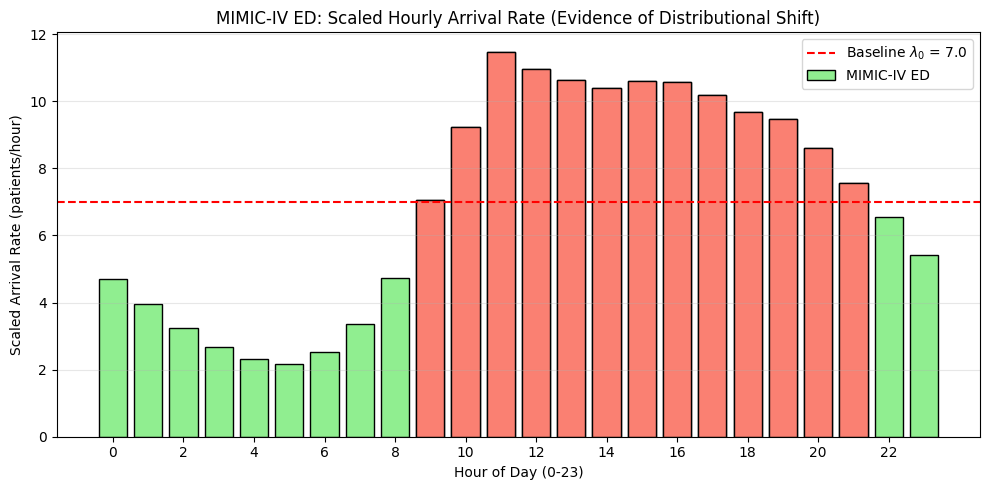

In [5]:
# merge dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "/home/math_sutarman/Rina_paper"
edstays_path = os.path.join(DATA_DIR, "edstays.csv")
triage_path = os.path.join(DATA_DIR, "triage.csv")

# 1. Muat data
df_ed = pd.read_csv(edstays_path, usecols=['stay_id', 'intime', 'outtime'], parse_dates=['intime', 'outtime'])
df_triage = pd.read_csv(triage_path, usecols=['stay_id', 'acuity'])

# 2. Merge dan filter
df_merged = pd.merge(df_ed, df_triage, on='stay_id', how='inner')
df_merged = df_merged[df_merged['acuity'].between(1, 5)].copy()
df_merged['acuity'] = df_merged['acuity'].astype(int)

# 3. Hitung LoS
valid_los = df_merged['outtime'].notna()
df_merged['los_minutes'] = np.nan
df_merged.loc[valid_los, 'los_minutes'] = (df_merged.loc[valid_los, 'outtime'] - df_merged.loc[valid_los, 'intime']).dt.total_seconds() / 60
df_los_clean = df_merged[(df_merged['los_minutes'] >= 5) & (df_merged['los_minutes'] <= 2880)].copy()

# 4. PERBAIKAN: Hitung jumlah hari berdasarkan tanggal unik (bukan max - min)
df_merged['date_only'] = df_merged['intime'].dt.date
num_days_unique = df_merged['date_only'].nunique()
print(f"Jumlah hari unik yang valid dalam dataset: {num_days_unique} hari")

# 5. Distribusi Triage (P_TRIAGE)
triage_counts = df_merged['acuity'].value_counts().sort_index()
P_TRIAGE_MIMIC = (triage_counts / triage_counts.sum()).values
print(f"\nMIMIC-IV P_TRIAGE: {np.round(P_TRIAGE_MIMIC, 4)}")

# 6. Laju Kedatangan Per Jam (lambda_h)
df_merged['arrival_hour'] = df_merged['intime'].dt.hour
hourly_counts = df_merged['arrival_hour'].value_counts().sort_index()

# Pastikan array lengkap dari jam 0-23
hourly_counts = hourly_counts.reindex(range(24), fill_value=0)
lambda_h_raw = hourly_counts / num_days_unique

print(f"\nRata-rata kedatangan global (lambda_0 raw): {lambda_h_raw.mean():.2f} pasien/jam")

# 7. Scaling ke Baseline Model Anda (misal: LAMBDA_0 = 7.0 seperti di notebook)
LAMBDA_0_MODEL = 7.0
# Hitung faktor skala berdasarkan rata-rata
scale_factor = LAMBDA_0_MODEL / lambda_h_raw.mean()
LAMBDA_H_MIMIC = lambda_h_raw.values * scale_factor

print(f"\nLAMBDA_H MIMIC-IV (Scaled to lambda_0 = {LAMBDA_0_MODEL}):")
print(np.round(LAMBDA_H_MIMIC, 4))

# 8. Plot Distribusi Shift MIMIC-IV
plt.figure(figsize=(10, 5))
plt.bar(range(24), LAMBDA_H_MIMIC, color='lightgreen', edgecolor='black', label='MIMIC-IV ED')
plt.axhline(LAMBDA_0_MODEL, color='red', linestyle='--', label=f'Baseline $\lambda_0$ = {LAMBDA_0_MODEL}')

upward_hours = np.where(LAMBDA_H_MIMIC > LAMBDA_0_MODEL)[0]
for h in upward_hours:
    plt.bar(h, LAMBDA_H_MIMIC[h], color='salmon', edgecolor='black')

plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Scaled Arrival Rate (patients/hour)')
plt.title('MIMIC-IV ED: Scaled Hourly Arrival Rate (Evidence of Distributional Shift)')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
#memilih dataset
# =========================================================
# PILIH DATASET: 'NHAMCS' atau 'MIMIC_IV'
# =========================================================
ACTIVE_DATASET = 'MIMIC_IV'  # Ubah ke 'NHAMCS' jika ingin kembali ke data lama

if ACTIVE_DATASET == 'MIMIC_IV':
    print("Menggunakan parameter kalibrasi MIMIC-IV ED...")
    
    # Distribusi Triage MIMIC-IV (ESI 1 sampai 5)
    P_TRIAGE = np.array([
        0.0574,  # ESI 1 (Resuscitation)
        0.3334,  # ESI 2 (Emergent)
        0.5383,  # ESI 3 (Urgent) - Dominan di MIMIC-IV
        0.0682,  # ESI 4 (Less Urgent)
        0.0026   # ESI 5 (Non-urgent)
    ], dtype=float)
    
    # Profil LAMBDA_H MIMIC-IV (Scaled to lambda_0 = 7.0)
    # Puncak demand terjadi pada jam 10:00 - 17:00
    LAMBDA_H = np.array([
        4.6997,  # 00:00
        3.9587,  # 01:00
        3.2290,  # 02:00
        2.6797,  # 03:00
        2.3080,  # 04:00
        2.1807,  # 05:00
        2.5238,  # 06:00
        3.3483,  # 07:00
        4.7262,  # 08:00
        7.0527,  # 09:00
        9.2217,  # 10:00
        11.4799, # 11:00 (Peak)
        10.9507, # 12:00
        10.6321, # 13:00
        10.3810, # 14:00
        10.6068, # 15:00
        10.5847, # 16:00
        10.1829, # 17:00
        9.6722,  # 18:00
        9.4596,  # 19:00
        8.5925,  # 20:00
        7.5546,  # 21:00
        6.5565,  # 22:00
        5.4181   # 23:00
    ], dtype=float)

else:
    print("Menggunakan parameter kalibrasi NHAMCS...")
    P_TRIAGE = np.array([0.042868, 0.150370, 0.504397, 0.266113, 0.036251], dtype=float)
    LAMBDA_H = np.array([
        4.0568, 2.9891, 3.1196, 2.7943, 2.1183, 2.5431, 2.9578, 4.9179,
        6.9377, 8.6291, 10.3772, 9.8808, 10.4083, 10.7269, 9.1987, 10.2179,
        10.0234, 10.3836, 9.5743, 8.8545, 8.8165, 7.2792, 6.4507, 4.7443
    ], dtype=float)

# Normalisasi untuk memastikan probabilitas = 1.0
P_TRIAGE = P_TRIAGE / P_TRIAGE.sum()

print(f"Dataset Aktif: {ACTIVE_DATASET}")
print(f"Sum P_TRIAGE: {P_TRIAGE.sum():.4f}")
print(f"Mean LAMBDA_H: {LAMBDA_H.mean():.4f}")

Menggunakan parameter kalibrasi MIMIC-IV ED...
Dataset Aktif: MIMIC_IV
Sum P_TRIAGE: 1.0000
Mean LAMBDA_H: 7.0000


In [ ]:
## Main Code ##

In [1]:
# ============================================================
# CELL 1: IMPORTS & GLOBAL CONFIGURATION
# ============================================================
import numpy as np
import pandas as pd
import os, json, time, glob, itertools
from datetime import datetime
from scipy.stats import poisson
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ---- Path ----
DATA_DIR = "/home/math_sutarman/Rina_paper"
OUTPUT_DIR = os.path.join(DATA_DIR, "results_json")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- MDP Parameters ----
K_DP        = 3            # Max queue level per triage class
D           = 3            # Number of physicians
DELTA_H     = 1.0 / 12.0  # 5 minutes in hours
HORIZON_MIN = 480          # 8-hour shift
T           = HORIZON_MIN // 5  # 96 epochs
GAMMA       = 0.95
ALPHA       = np.array([5, 4, 3, 2, 1], dtype=float)  # Waiting cost weights
MU          = 2.5          # Service rate (patients/hour)
P_COMPLETE  = 1.0 - np.exp(-MU * DELTA_H)
LAMBDA_0    = 7.0          # Baseline arrival rate

# ---- Solver Parameters ----
TOL_VI      = 1e-6
MAX_ITER_VI = 1000
RHO_GRID    = np.linspace(0.0, 0.15, 30)   # Lambda grid for Wasserstein dual
N_REPS      = 30                            # Monte Carlo replications

# ---- DC-AWRVI Parameters ----
RHO_BASE    = 0.005
RHO_MAX     = 0.05
OMEGA_RHO   = 0.85   # Smoothing parameter for adaptive rho
N_RHO_LIB   = 8      # Number of rho values in policy library

print("Configuration loaded successfully.")
print(f"  State space size : {(K_DP+1)**5}")
print(f"  Epochs           : {T}")
print(f"  Replications     : {N_REPS}")
print(f"  Output directory : {OUTPUT_DIR}")

Configuration loaded successfully.
  State space size : 1024
  Epochs           : 96
  Replications     : 30
  Output directory : /home/math_sutarman/Rina_paper/results_json


In [2]:
# ============================================================
# CELL 2: DATA LOADERS (DIPERBAIKI: Filter Tahun & Typo int32)
# ============================================================

def load_mimic_iv(data_dir):
    """Load and calibrate MIMIC-IV ED dataset (Robust to date parsing anomalies)."""
    ed_path = os.path.join(data_dir, "edstays.csv")
    tr_path = os.path.join(data_dir, "triage.csv")
    
    print("  [INFO] Membaca edstays.csv dan triage.csv...")
    df_ed = pd.read_csv(ed_path, usecols=['stay_id','intime','outtime'], parse_dates=['intime','outtime'])
    df_tr = pd.read_csv(tr_path, usecols=['stay_id','acuity'])
    
    df = pd.merge(df_ed, df_tr, on='stay_id', how='inner')
    
    # 1. Filter hanya acuity 1-5
    df = df[df['acuity'].between(1, 5)].copy()
    df['acuity'] = df['acuity'].astype(int)
    
    # 2. PERBAIKAN: Paksa parsing datetime dan buang yang benar-benar error (NaT)
    df['intime'] = pd.to_datetime(df['intime'], errors='coerce')
    df = df.dropna(subset=['intime']).copy()
    
    # Kita tidak memfilter tahun lagi, karena jam dan triage adalah yang terpenting.
    # Anomali tahun (misal 2110) tidak mempengaruhi perhitungan jam (0-23) atau jumlah hari unik.
    
    if len(df) == 0:
        raise ValueError("DataFrame MIMIC-IV kosong setelah membersihkan nilai waktu yang rusak (NaT).")
    
    # --- SAFEGUARD P_TRIAGE ---
    p_triage_raw = df['acuity'].value_counts()
    p_triage = np.zeros(5)
    for level in range(1, 6):
        if level in p_triage_raw.index:
            p_triage[level-1] = p_triage_raw[level]
    
    total = p_triage.sum()
    if total > 0:
        p_triage = p_triage / total
    else:
        raise ValueError("Tidak ada data triage valid (1-5) yang ditemukan!")
    # --------------------------
    
    # LoS (Length of Stay)
    df['outtime'] = pd.to_datetime(df['outtime'], errors='coerce')
    valid = df['outtime'].notna()
    df['los_min'] = np.nan
    df.loc[valid, 'los_min'] = (df.loc[valid,'outtime'] - df.loc[valid,'intime']).dt.total_seconds()/60
    df_los = df[(df['los_min'] >= 5) & (df['los_min'] <= 2880)]
    
    # Lambda_h
    df['hour'] = df['intime'].dt.hour
    df['date_only'] = df['intime'].dt.date # Untuk menghitung jumlah hari unik
    
    hc = df['hour'].value_counts().sort_index().reindex(range(24), fill_value=0)
    n_days = df['date_only'].nunique()
    
    # Cegah pembagian dengan nol
    n_days = max(1, n_days)
    lambda_h_raw = hc.values / n_days
    
    # Scale to LAMBDA_0
    scale = LAMBDA_0 / max(1e-9, lambda_h_raw.mean())
    lambda_h = lambda_h_raw * scale
    
    return {
        "name": "MIMIC_IV",
        "source": "MIMIC-IV ED (Beth Israel Deaconess)",
        "n_records": len(df),
        "n_days": n_days,
        "P_TRIAGE": p_triage,
        "LAMBDA_H": lambda_h,
        "lambda_0": LAMBDA_0,
        "mean_los_min": float(df_los['los_min'].mean()) if len(df_los) > 0 else 240.0,
        "mu_calibrated": MU
    }


def load_nhamcs(file_path, year_label):
    """Load and calibrate NHAMCS dataset."""
    needed = ['ARRTIME','IMMEDR','LOV','VMONTH','VDAYR']
    hdr = pd.read_csv(file_path, nrows=0)
    available = [c for c in needed if c in hdr.columns]
    
    if len(available) < 3:
        print(f"  [WARN] {year_label}: Missing key columns. Available: {available}")
        return None
    
    df = pd.read_csv(file_path, usecols=available, low_memory=False)
    
    # --- SAFEGUARD P_TRIAGE ---
    p_triage = np.array([0.04, 0.15, 0.50, 0.27, 0.04]) # Default fallback
    if 'IMMEDR' in df.columns:
        df_valid = df[df['IMMEDR'].between(1, 5)].copy()
        if len(df_valid) > 0:
            # --- PERBAIKAN TYPO int32 -> int ---
            df_valid['IMMEDR'] = df_valid['IMMEDR'].astype(int)
            tc = df_valid['IMMEDR'].value_counts()
            p_temp = np.zeros(5)
            for level in range(1, 6):
                if level in tc.index:
                    p_temp[level-1] = tc[level]
            if p_temp.sum() > 0:
                p_triage = p_temp / p_temp.sum()
            df = df_valid # Use filtered df for lambda calculation
    # --------------------------
    
    # Parse ARRTIME
    if 'ARRTIME' in df.columns:
        df = df[df['ARRTIME'].between(0, 2359)].copy()
        df['hour'] = (df['ARRTIME'] // 100).astype(int)
        df = df[df['hour'].between(0, 23)]
        hc = df['hour'].value_counts().sort_index().reindex(range(24), fill_value=0)
        
        if 'VMONTH' in df.columns and 'VDAYR' in df.columns:
            n_days = df.groupby(['VMONTH','VDAYR']).ngroups
        else:
            n_days = max(1, len(df) // 50)
        
        lambda_h_raw = hc.values / max(1, n_days)
        scale = LAMBDA_0 / max(1e-9, lambda_h_raw.mean())
        lambda_h = lambda_h_raw * scale
    else:
        lambda_h = np.full(24, LAMBDA_0)
        n_days = 0
    
    return {
        "name": f"NHAMCS_{year_label}",
        "source": f"NHAMCS {year_label} Emergency Department",
        "n_records": len(df),
        "n_days": n_days,
        "P_TRIAGE": p_triage,
        "LAMBDA_H": lambda_h,
        "lambda_0": LAMBDA_0,
        "mean_los_min": float(df['LOV'].mean()) if 'LOV' in df.columns else 240.0,
        "mu_calibrated": MU
    }


def generate_synthetic(scenario_name):
    """Generate synthetic arrival profiles."""
    p_triage_default = np.array([0.05, 0.15, 0.50, 0.26, 0.04])
    hours = np.arange(24)
    
    if scenario_name == "Nominal":
        lambda_h = np.full(24, LAMBDA_0)
    elif scenario_name == "Diurnal":
        lambda_h = LAMBDA_0 + 3.5 * np.sin(np.pi * (hours - 6) / 12)
        lambda_h = np.clip(lambda_h, 1.0, 15.0)
    elif scenario_name == "Surge":
        lambda_h = np.full(24, LAMBDA_0)
        lambda_h[10:17] = LAMBDA_0 * 1.8
    elif scenario_name == "Controlled_Surge":
        lambda_h = np.full(24, LAMBDA_0 * 0.7)
        for h in range(8, 14):
            lambda_h[h] = LAMBDA_0 * (0.7 + 0.2 * (h - 7))
        for h in range(14, 20):
            lambda_h[h] = LAMBDA_0 * (1.9 - 0.2 * (h - 13))
        lambda_h = np.clip(lambda_h, 1.0, 15.0)
    else:
        raise ValueError(f"Unknown scenario: {scenario_name}")
    
    lambda_h = lambda_h * (LAMBDA_0 / max(1e-9, lambda_h.mean()))
    
    return {
        "name": f"Synthetic_{scenario_name}",
        "source": f"Synthetic ({scenario_name})",
        "n_records": -1,
        "n_days": -1,
        "P_TRIAGE": p_triage_default,
        "LAMBDA_H": lambda_h,
        "lambda_0": LAMBDA_0,
        "mean_los_min": 240.0,
        "mu_calibrated": MU
    }


# ---- Load All Datasets ----
print("Loading datasets...")
all_datasets = {}

# Real 1: MIMIC-IV
try:
    ds = load_mimic_iv(DATA_DIR)
    all_datasets[ds["name"]] = ds
    print(f"  [OK] {ds['name']}: {ds['n_records']} records, {ds['n_days']} days")
    print(f"       P_TRIAGE shape: {ds['P_TRIAGE'].shape}, sum: {ds['P_TRIAGE'].sum():.4f}")
except Exception as e:
    print(f"  [FAIL] MIMIC-IV: {e}")

# Real 2 & 3: NHAMCS 2019, 2021
for yr in ["2019", "2021"]:
    fp = os.path.join(DATA_DIR, f"ed_{yr}.csv")
    if os.path.exists(fp):
        try:
            ds = load_nhamcs(fp, yr)
            if ds:
                all_datasets[ds["name"]] = ds
                print(f"  [OK] {ds['name']}: {ds['n_records']} records, {ds['n_days']} days")
        except Exception as e:
            print(f"  [FAIL] NHAMCS {yr}: {e}")

# Synthetic
for sc in ["Nominal", "Diurnal", "Surge", "Controlled_Surge"]:
    ds = generate_synthetic(sc)
    all_datasets[ds["name"]] = ds
    print(f"  [OK] {ds['name']}")

print(f"\nTotal datasets loaded: {len(all_datasets)}")

Loading datasets...
  [INFO] Membaca edstays.csv dan triage.csv...
  [OK] MIMIC_IV: 418100 records, 35997 days
       P_TRIAGE shape: (5,), sum: 1.0000
  [OK] NHAMCS_2019: 13015 records, 84 days
  [OK] NHAMCS_2021: 10423 records, 84 days
  [OK] Synthetic_Nominal
  [OK] Synthetic_Diurnal
  [OK] Synthetic_Surge
  [OK] Synthetic_Controlled_Surge

Total datasets loaded: 7


In [3]:
# ============================================================
# CELL 3: MDP CORE (DIPERBAIKI: Validasi p_triage eksplisit)
# ============================================================
import math

def build_state_space(K):
    states = list(itertools.product(range(K+1), repeat=5))
    return np.array(states, dtype=int)

def build_action_space(D, n_queues=5):
    actions = []
    for combo in itertools.product(range(D+1), repeat=n_queues):
        if sum(combo) <= D:
            actions.append(combo)
    return np.array(actions, dtype=int)

def build_transition_tensor(states, actions, lambda_h_hour, p_triage, p_complete, K):
    """
    Build P0[s_idx, a_idx, s'_idx] for a given hour's lambda.
    """
    # --- SAFEGUARD KRITIS ---
    p_triage = np.asarray(p_triage, dtype=float).flatten()
    if len(p_triage) != 5:
        raise ValueError(f"ERROR KRITIS: p_triage harus memiliki panjang 5, tetapi mendapatkan panjang {len(p_triage)}. Nilai: {p_triage}")
    # ------------------------
    
    n_s = len(states)
    n_a = len(actions)
    P0 = np.zeros((n_s, n_a, n_s), dtype=np.float64)
    
    state_to_idx = {tuple(s): i for i, s in enumerate(states)}
    lam = lambda_h_hour * DELTA_H
    
    max_arr = min(int(lam + 6*np.sqrt(max(lam,1)) + 5), 30)
    arr_probs = np.array([poisson.pmf(k, lam) for k in range(max_arr+1)])
    arr_probs[-1] += 1.0 - arr_probs.sum()
    
    for si, s in enumerate(states):
        for ai, a in enumerate(actions):
            comp_dists = []
            for q in range(5):
                n_servers = min(s[q], a[q])
                probs = np.array([
                    (math.comb(n_servers, k) * p_complete**k * (1-p_complete)**(n_servers-k))
                    if k <= n_servers else 0.0
                    for k in range(n_servers + 1)
                ])
                comp_dists.append(probs)
            
            comp_ranges = [range(len(cd)) for cd in comp_dists]
            
            for comp_tuple in itertools.product(*comp_ranges):
                comp_prob = 1.0
                for q in range(5):
                    comp_prob *= comp_dists[q][comp_tuple[q]]
                
                if comp_prob < 1e-12:
                    continue
                
                s_post = np.array([s[q] - comp_tuple[q] for q in range(5)])
                
                for total_arr in range(max_arr + 1):
                    if arr_probs[total_arr] < 1e-12:
                        continue
                    
                    if total_arr <= 15:
                        for arr_split in _multinomial_splits(total_arr, 5):
                            arr_prob = (math.factorial(total_arr) / 
                                       np.prod([math.factorial(x) for x in arr_split]) *
                                       np.prod([p_triage[q]**arr_split[q] for q in range(5)]))
                            
                            s_new = np.array([min(s_post[q] + arr_split[q], K) for q in range(5)])
                            sj = state_to_idx[tuple(s_new)]
                            P0[si, ai, sj] += comp_prob * arr_probs[total_arr] * arr_prob
                    else:
                        arr_split = np.round(np.array(p_triage) * total_arr).astype(int)
                        diff = total_arr - arr_split.sum()
                        if diff > 0:
                            for _ in range(diff):
                                arr_split[np.argmax(p_triage)] += 1
                        elif diff < 0:
                            for _ in range(-diff):
                                idx = np.argmax(arr_split)
                                if arr_split[idx] > 0:
                                    arr_split[idx] -= 1
                        
                        s_new = np.array([min(s_post[q] + arr_split[q], K) for q in range(5)])
                        sj = state_to_idx[tuple(s_new)]
                        P0[si, ai, sj] += comp_prob * arr_probs[total_arr]
    
    row_sums = P0.sum(axis=2, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    P0 /= row_sums
    
    return P0


def _multinomial_splits(n, k):
    if k == 1:
        yield (n,)
        return
    for i in range(n + 1):
        for rest in _multinomial_splits(n - i, k - 1):
            yield (i,) + rest


def compute_cost(states, alpha, K):
    return np.array([np.dot(alpha, s) for s in states], dtype=np.float64)


# Build state and action spaces once
STATES  = build_state_space(K_DP)
ACTIONS = build_action_space(D)
COST_VEC = compute_cost(STATES, ALPHA, K_DP)
STATE_IDX = {tuple(s): i for i, s in enumerate(STATES)}

print(f"States : {len(STATES)}")
print(f"Actions: {len(ACTIONS)}")
print(f"Cost range: [{COST_VEC.min():.1f}, {COST_VEC.max():.1f}]")

States : 1024
Actions: 56
Cost range: [0.0, 45.0]


In [4]:
# ============================================================
# CELL 4: SOLVERS
# ============================================================

def solve_nvi(P0, cost, gamma, tol=TOL_VI, max_iter=MAX_ITER_VI):
    """Nominal Value Iteration."""
    n_s, n_a, _ = P0.shape
    V = np.zeros(n_s)
    
    for it in range(max_iter):
        Q = cost[:, None] + gamma * P0 @ V  # (n_s, n_a)
        V_new = Q.min(axis=1)
        res = np.max(np.abs(V_new - V))
        V = V_new
        if res < tol:
            break
    
    # Extract greedy policy
    Q = cost[:, None] + gamma * P0 @ V
    policy = Q.argmin(axis=1)
    return {"V": V, "policy": policy, "iterations": it+1, "converged": res < tol}


def wasserstein_robust_Q(P0, V, rho, states_arr, rho_grid=RHO_GRID):
    """
    Compute robust Q-values using Wasserstein dual.
    Q_rob(s,a) = min_{lam>=0} { lam*rho + E_P0[ max_s'' (V(s'') - lam*d(s',s'')) ] }
    """
    n_s = len(states_arr)
    
    # Pairwise L1 distance matrix (precomputable, but kept here for clarity)
    diff = states_arr[:, None, :] - states_arr[None, :, :]
    dist = np.sum(np.abs(diff), axis=2).astype(np.float64)  # (n_s, n_s)
    
    # For each lambda in grid, compute phi[i] = max_j [V[j] - lam * dist[i,j]]
    phi_matrix = np.zeros((len(rho_grid), n_s))
    for i, lam in enumerate(rho_grid):
        phi_matrix[i] = np.max(V[None, :] - lam * dist, axis=1)
    
    # robust_Q_all[s, a, lambda_idx] = lam*rho + P0[s,a,:] @ phi[lambda_idx,:]
    # P0 @ phi_matrix.T -> (n_s, n_a, n_lambda)
    robust_Q_all = P0 @ phi_matrix.T
    robust_Q_all += rho_grid * rho  # broadcast (n_lambda,)
    
    # Min over lambda
    robust_Q = np.min(robust_Q_all, axis=2)  # (n_s, n_a)
    return robust_Q


def solve_frvi(P0, cost, gamma, rho, states_arr, tol=TOL_VI, max_iter=MAX_ITER_VI):
    """Fixed Robust Value Iteration with Wasserstein radius rho."""
    n_s, n_a, _ = P0.shape
    V = np.zeros(n_s)
    
    for it in range(max_iter):
        Q_rob = wasserstein_robust_Q(P0, V, rho, states_arr)
        Q = cost[:, None] + gamma * Q_rob
        V_new = Q.min(axis=1)
        res = np.max(np.abs(V_new - V))
        V = V_new
        if res < tol:
            break
    
    Q_rob = wasserstein_robust_Q(P0, V, rho, states_arr)
    Q = cost[:, None] + gamma * Q_rob
    policy = Q.argmin(axis=1)
    return {"V": V, "policy": policy, "rho": rho, "iterations": it+1, "converged": res < tol}


def calibrate_rho_base(lambda_h, p_triage, P0_nominal, states_arr, cost, gamma):
    """
    Data-calibrated rho: use quantile of empirical Wasserstein distances
    between hourly transition kernels and the nominal kernel.
    Simplified: rho_base ~ std(lambda_h) / mean(lambda_h) * scaling_factor.
    """
    shift_scores = np.abs(lambda_h - lambda_h.mean()) / (lambda_h.mean() + 1e-9)
    rho_base = float(np.median(shift_scores) * 0.02)
    rho_max  = float(np.max(shift_scores) * 0.05)
    rho_base = max(rho_base, 0.001)
    rho_max  = max(rho_max, rho_base * 2)
    return rho_base, rho_max


def solve_dc_awrvi(P0, cost, gamma, lambda_h, states_arr, 
                   rho_base=RHO_BASE, rho_max=RHO_MAX, n_lib=N_RHO_LIB,
                   tol=TOL_VI, max_iter=MAX_ITER_VI):
    """
    Data-Calibrated Adaptive Wasserstein RVI.
    1. Build policy library for different rho values.
    2. Map each hour to a rho based on distributional shift.
    """
    rho_lib = np.linspace(rho_base, rho_max, n_lib)
    policy_lib = {}
    
    print(f"  Building policy library ({n_lib} rho values)...")
    for rho_val in rho_lib:
        res = solve_frvi(P0, cost, gamma, rho_val, states_arr, tol, max_iter)
        policy_lib[float(rho_val)] = res["policy"]
        print(f"    rho={rho_val:.5f} | iter={res['iterations']} | conv={res['converged']}")
    
    # Adaptive mapping: hour -> rho
    shift = (lambda_h - lambda_h.mean()) / (lambda_h.max() - lambda_h.min() + 1e-9)
    shift_norm = (shift - shift.min()) / (shift.max() - shift.min() + 1e-9)
    
    hour_to_rho = {}
    for h in range(24):
        rho_h = rho_base + (rho_max - rho_base) * shift_norm[h]
        # Snap to nearest library rho
        nearest_rho = rho_lib[np.argmin(np.abs(rho_lib - rho_h))]
        hour_to_rho[h] = float(nearest_rho)
    
    return {
        "policy_lib": policy_lib,
        "hour_to_rho": hour_to_rho,
        "rho_base": rho_base,
        "rho_max": rho_max,
        "rho_lib": rho_lib.tolist()
    }


print("Solver functions defined.")

Solver functions defined.


In [10]:
# =========================================================
# CELL 5: MONTE CARLO SIMULATOR & METRICS (DIPERBAIKI)
# =========================================================

def simulate_policy(policy_input, method_name, lambda_h, p_triage, p_complete, K, D, alpha, T, n_reps, seed_base):
    """Run Monte Carlo simulation of a policy over T epochs."""
    all_costs = []
    all_queues = []
    all_overflows = []
    
    for rep in range(n_reps):
        rng = np.random.RandomState(seed_base + rep)
        state = np.zeros(5, dtype=int)
        total_cost = 0.0
        queue_history = []
        overflow_total = 0
        busy_slots = 0
        
        for t in range(T):
            hour = (t * 5) // 60  # Map epoch to hour (0-23)
            hour = min(hour, 23)
            lam = lambda_h[hour] * DELTA_H
            
            # Get action from policy
            si = STATE_IDX[tuple(state)]
            
            if method_name == "DC-AWRVI":
                # Untuk DC-AWRVI, policy_input adalah dictionary
                rho_h = policy_input["hour_to_rho"][hour]
                policy = policy_input["policy_lib"][rho_h]
                action = ACTIONS[policy[si]]
            else:
                # PERBAIKAN: Untuk NVI, FRVI, CV-FRVI, Entropic, 
                # policy_input adalah array kebijakan langsung, bukan dictionary.
                action = ACTIONS[policy_input[si]]
            
            # Cost
            c = np.dot(alpha, state)
            total_cost += c
            queue_history.append(state.sum())
            
            # Service completions
            for q in range(5):
                n_srv = min(state[q], action[q])
                if n_srv > 0:
                    comps = rng.binomial(n_srv, p_complete)
                    state[q] -= comps
                    busy_slots += action[q]
            
            # Arrivals
            total_arr = rng.poisson(lam)
            if total_arr > 0:
                arrivals = rng.multinomial(total_arr, p_triage)
                for q in range(5):
                    new_n = state[q] + arrivals[q]
                    if new_n > K:
                        overflow_total += (new_n - K)
                    state[q] = min(new_n, K)
        
        all_costs.append(total_cost)
        all_queues.append(queue_history)
        all_overflows.append(overflow_total)
    
    return {
        "costs": np.array(all_costs),
        "queues": np.array(all_queues),
        "overflows": np.array(all_overflows),
        "utilization": busy_slots / (D * T * n_reps) * 100 if n_reps > 0 else 0
    }


def compute_metrics(sim_result):
    """Compute summary metrics from simulation results."""
    costs = sim_result["costs"]
    queues = sim_result["queues"]
    overflows = sim_result["overflows"]
    
    sorted_costs = np.sort(costs)
    n = len(sorted_costs)
    cvar95_idx = int(np.ceil(0.95 * n))
    cvar95 = float(sorted_costs[cvar95_idx:].mean()) if cvar95_idx < n else float(sorted_costs[-1])
    
    return {
        "Mean_Cost": float(costs.mean()),
        "SD_Cost": float(costs.std()),
        "CVaR95": cvar95,
        "Mean_Queue": float(queues.mean()),
        "Peak_Queue": float(queues.max(axis=1).mean()),
        "Final_Queue": float(queues[:, -1].mean()),
        "Mean_Overflow": float(overflows.mean()),
        "Utilization_pct": float(sim_result["utilization"])
    }

print("Simulator and metrics functions defined (FIXED).")

Simulator and metrics functions defined (FIXED).


In [11]:
# =========================================================
# CELL BARU 1: ENTROPIC DRO & CV-TUNED FRVI (DIPERBAIKI)
# =========================================================
import numpy as np

def entropic_robust_value_iteration(P0, cost, gamma, eta, tol=1e-6, max_iter=500):
    """
    Entropic (KL-Divergence) Robust Value Iteration menggunakan tensor P0.
    Parameter eta (inverse temperature) mengontrol tingkat robustness.
    Semakin besar eta, semakin robust (mendekati worst-case).
    """
    n_s, n_a, _ = P0.shape
    V = np.zeros(n_s)
    
    for it in range(max_iter):
        # Entropic risk measure: (1/eta) * log( E_P0[exp(eta * V_next)] )
        # Kita hitung secara vectorized untuk kecepatan maksimal
        
        # 1. Hitung exp(eta * V)
        exp_V = np.exp(eta * V)
        
        # 2. Ekspektasi di bawah P0: E_P0[exp(eta * V)] -> shape (n_s, n_a)
        E_exp_V = P0 @ exp_V
        
        # 3. Cegah log(0) untuk stabilitas numerik
        E_exp_V = np.maximum(E_exp_V, 1e-300)
        
        # 4. Robust continuation value
        V_rob = (1.0 / eta) * np.log(E_exp_V)
        
        # 5. Bellman update
        Q = cost[:, None] + gamma * V_rob
        V_new = Q.min(axis=1)
        
        # 6. Cek konvergensi
        res = np.max(np.abs(V_new - V))
        V = V_new
        if res < tol:
            break
            
    # Ekstrak kebijakan final
    exp_V = np.exp(eta * V)
    E_exp_V = np.maximum(P0 @ exp_V, 1e-300)
    V_rob = (1.0 / eta) * np.log(E_exp_V)
    Q = cost[:, None] + gamma * V_rob
    policy = Q.argmin(axis=1)
    
    return {
        "V": V,
        "policy": policy,
        "eta": eta,
        "converged": res < tol,
        "iterations": it + 1
    }


def find_cv_tuned_rho(P0, cost, gamma, rho_grid, val_lambda_h, p_triage, p_complete, 
                      K, D, alpha, T, n_reps=20, seed_base=50000):
    """
    Cross-Validation untuk mencari rho optimal pada FRVI.
    (Melatih pada P0 nominal, memvalidasi pada data val_lambda_h)
    """
    print("  Running Cross-Validation for FRVI...")
    best_rho = rho_grid[0]
    best_val_cost = np.inf
    
    for rho in rho_grid:
        # Solve FRVI pada data training (menggunakan P0 nominal)
        res = solve_frvi(P0, cost, gamma, rho, STATES)
        policy = res["policy"]
        
        # Simulasi pada data VALIDASI
        sim_res = simulate_policy(policy, "FRVI", val_lambda_h, p_triage, p_complete, K, D, alpha, T, n_reps, seed_base)
        val_cost = sim_res["costs"].mean()
        
        if val_cost < best_val_cost:
            best_val_cost = val_cost
            best_rho = rho
            
    print(f"  [OK] CV-Tuned optimal rho = {best_rho:.6f} (Val Cost = {best_val_cost:.2f})")
    return best_rho

In [12]:
# =========================================================
# CELL BARU 2: COMPLEX SYNTHETIC SCENARIOS (OOD TESTING)
# =========================================================

def generate_ood_scenarios():
    """Generate 3 complex Out-of-Distribution scenarios."""
    scenarios = {}
    hours = np.arange(24)
    
    # 1. Mass Casualty Incident (MCI)
    # Normal for 4 hours, then extreme surge with heavy ESI 1-2 for 3 hours, then normal
    lambda_mci = np.full(24, 7.0)
    lambda_mci[8:11] = 25.0  # Extreme surge
    p_triage_mci = np.array([0.30, 0.50, 0.15, 0.05, 0.00]) # Heavy critical patients
    
    scenarios["Synthetic_MCI"] = {
        "name": "Synthetic_MCI",
        "source": "Synthetic (Mass Casualty Incident)",
        "P_TRIAGE": p_triage_mci,
        "LAMBDA_H": lambda_mci,
        "lambda_0": 7.0,
        "ood_type": "Extreme Surge + Triage Shift"
    }
    
    # 2. Heavy-Tailed Length of Stay (Log-Normal)
    # We keep the same lambda, but we will flag the simulator to use Log-Normal LoS
    # For the MDP solver, it still uses exponential (p_complete), creating model misspecification
    lambda_ht = np.full(24, 7.0)
    lambda_ht[10:18] = 9.0 # Slight diurnal shift
    p_triage_ht = np.array([0.05, 0.15, 0.50, 0.26, 0.04])
    
    scenarios["Synthetic_HeavyTail"] = {
        "name": "Synthetic_HeavyTail",
        "source": "Synthetic (Log-Normal LoS)",
        "P_TRIAGE": p_triage_ht,
        "LAMBDA_H": lambda_ht,
        "lambda_0": 7.0,
        "ood_type": "Model Misspecification (Heavy-Tailed Service)"
    }
    
    # 3. Capacity Degradation
    # Normal arrival, but physician capacity drops suddenly
    lambda_cap = np.full(24, 8.0) # Slightly high baseline
    p_triage_cap = np.array([0.05, 0.15, 0.50, 0.26, 0.04])
    
    scenarios["Synthetic_CapacityDrop"] = {
        "name": "Synthetic_CapacityDrop",
        "source": "Synthetic (Capacity Degradation)",
        "P_TRIAGE": p_triage_cap,
        "LAMBDA_H": lambda_cap,
        "lambda_0": 7.0,
        "ood_type": "Sudden Capacity Loss (D=3 -> D=1)"
    }
    
    return scenarios

OOD_SCENARIOS = generate_ood_scenarios()
print("OOD Scenarios generated:")
for k, v in OOD_SCENARIOS.items():
    print(f"  {k}: {v['ood_type']}")

OOD Scenarios generated:
  Synthetic_MCI: Extreme Surge + Triage Shift
  Synthetic_HeavyTail: Model Misspecification (Heavy-Tailed Service)
  Synthetic_CapacityDrop: Sudden Capacity Loss (D=3 -> D=1)


In [15]:
# =========================================================
# CELL BARU 3: OOD SIMULATOR (DIPERBAIKI LENGKAP)
# =========================================================

def simulate_policy_ood(policy, method_name, lambda_h, p_triage, p_complete, K, D, alpha, T, n_reps, seed_base, ood_type="Normal"):
    """
    Enhanced simulator that can handle OOD conditions:
    - HeavyTail: Uses Log-Normal service times instead of Bernoulli(p_complete)
    - CapacityDrop: Reduces D to 1 during epochs 40-60
    """
    all_costs = []
    all_queues = []
    all_overflows = []
    
    for rep in range(n_reps):
        rng = np.random.RandomState(seed_base + rep)
        state = np.zeros(5, dtype=int)
        total_cost = 0.0
        queue_history = []
        overflow_total = 0
        busy_slots = 0
        
        for t in range(T):
            hour = (t * 5) // 60
            hour = min(hour, 23)
            lam = lambda_h[hour] * DELTA_H
            
            si = STATE_IDX[tuple(state)]
            
            # Ambil action berdasarkan metode
            if method_name == "DC-AWRVI":
                # policy adalah dictionary untuk DC-AWRVI
                rho_h = policy["hour_to_rho"][hour]
                policy_t = policy["policy_lib"][rho_h]
                action = ACTIONS[policy_t[si]]
            else:
                # policy adalah array langsung untuk NVI, FRVI, CV-FRVI, Entropic
                action = ACTIONS[policy[si]]
            
            # Hitung biaya
            c = np.dot(alpha, state)
            total_cost += c
            queue_history.append(state.sum())
            
            # --- OOD: Capacity Degradation ---
            current_D = D
            if ood_type == "Sudden Capacity Loss (D=3 -> D=1)":
                if 40 <= t <= 60:
                    current_D = 1
            
            # Service completions
            for q in range(5):
                n_srv = min(state[q], action[q], current_D) # Batasi oleh current_D
                if n_srv > 0:
                    if ood_type == "Model Misspecification (Heavy-Tailed Service)":
                        # Log-Normal service time (model misspecification test)
                        for _ in range(n_srv):
                            if state[q] > 0:
                                lognormal_draw = rng.lognormal(mean=1.5, sigma=0.8)
                                prob_complete = min(1.0, 1.0 / max(1e-9, lognormal_draw))
                                if rng.rand() < prob_complete:
                                    state[q] -= 1
                    else:
                        comps = rng.binomial(n_srv, p_complete)
                        state[q] -= comps
                        busy_slots += n_srv
            
            # Arrivals
            total_arr = rng.poisson(lam)
            if total_arr > 0:
                arrivals = rng.multinomial(total_arr, p_triage)
                for q in range(5):
                    new_n = state[q] + arrivals[q]
                    if new_n > K:
                        overflow_total += (new_n - K)
                    state[q] = min(new_n, K)
        
        all_costs.append(total_cost)
        all_queues.append(queue_history)
        all_overflows.append(overflow_total)
        
    return {
        "costs": np.array(all_costs),
        "queues": np.array(all_queues),
        "overflows": np.array(all_overflows),
        "utilization": busy_slots / (D * T * n_reps) * 100 if n_reps > 0 else 0
    }

In [17]:
# =========================================================
# CELL 6: JSON EXPORT UTILITY
# =========================================================
import json
import os
from datetime import datetime

class NumpyEncoder(json.JSONEncoder):
    """Handle numpy types in JSON serialization."""
    def default(self, obj):
        if isinstance(obj, (np.integer,)): return int(obj)
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        if isinstance(obj, np.bool_): return bool(obj)
        return super().default(obj)

def save_results_json(all_results, output_dir):
    """Save all experiment results to a single JSON file."""
    # Pastikan direktori output ada
    os.makedirs(output_dir, exist_ok=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"experiment_results_{timestamp}.json"
    filepath = os.path.join(output_dir, filename)
    
    with open(filepath, 'w') as f:
        json.dump(all_results, f, cls=NumpyEncoder, indent=2)
    
    print(f"\n[SAVED] Results exported to: {filepath}")
    return filepath

print("JSON export utility defined successfully.")

JSON export utility defined successfully.


In [18]:
# =========================================================
# CELL BARU 4: GRAND PIPELINE (ALL METHODS x ALL DATASETS)
# =========================================================

METHODS_GRAND = ["NVI", "FRVI", "CV-FRVI", "Entropic-DRO", "DC-AWRVI"]
grand_results = {
    "metadata": {"timestamp": datetime.now().isoformat()},
    "datasets": {}
}

# Gabungkan semua dataset dan skenario OOD
ALL_TEST_ENVS = {}
ALL_TEST_ENVS.update(all_datasets)       # MIMIC, NHAMCS 2019, NHAMCS 2021, Synthetic
ALL_TEST_ENVS.update(OOD_SCENARIOS)      # MCI, HeavyTail, CapacityDrop

# 0. Build Nominal P0 (menggunakan lambda rata-rata dan p_triage default untuk baseline)
print("Building nominal transition tensor P0...")
P0_nominal = build_transition_tensor(STATES, ACTIONS, LAMBDA_0, np.array([0.05, 0.15, 0.50, 0.26, 0.04]), P_COMPLETE, K_DP)

# 1. Solve NVI (Hanya perlu 1 kali)
print("Solving NVI (Nominal)...")
nvi_res = solve_nvi(P0_nominal, COST_VEC, GAMMA)
NVI_POLICY = nvi_res["policy"]
print(f"  [OK] NVI converged in {nvi_res['iterations']} iterations")

# 2. Solve Entropic-DRO (Fixed eta sebagai benchmark)
print("Solving Entropic-DRO...")
ETA_BENCHMARK = 0.1
entropic_res = entropic_robust_value_iteration(P0_nominal, COST_VEC, GAMMA, eta=ETA_BENCHMARK)
ENTROPIC_POLICY = entropic_res["policy"]
print(f"  [OK] Entropic-DRO converged in {entropic_res['iterations']} iterations (eta={ETA_BENCHMARK})")

# 3. Solve CV-tuned FRVI (Train on NHAMCS 2019, Validate on NHAMCS 2021)
print("Solving CV-tuned FRVI...")
if "NHAMCS_2019" in all_datasets and "NHAMCS_2021" in all_datasets:
    val_lam = all_datasets["NHAMCS_2021"]["LAMBDA_H"]
    p_triage_train = all_datasets["NHAMCS_2019"]["P_TRIAGE"]
    
    rho_grid_cv = np.linspace(0.001, 0.05, 10)
    best_rho_cv = find_cv_tuned_rho(
        P0_nominal, COST_VEC, GAMMA, rho_grid_cv, 
        val_lam, p_triage_train, P_COMPLETE,
        K_DP, D, ALPHA, T, n_reps=10, seed_base=80000
    )
    
    cv_frvi_res = solve_frvi(P0_nominal, COST_VEC, GAMMA, best_rho_cv, STATES)
    CV_FRVI_POLICY = cv_frvi_res["policy"]
    print(f"  [OK] CV-FRVI solved with optimal rho = {best_rho_cv:.5f}")
else:
    print("  [WARN] Missing NHAMCS 2019/2021 for CV. Using default rho=0.01.")
    best_rho_cv = 0.01
    cv_frvi_res = solve_frvi(P0_nominal, COST_VEC, GAMMA, best_rho_cv, STATES)
    CV_FRVI_POLICY = cv_frvi_res["policy"]

# 4. Solve DC-AWRVI & FRVI untuk setiap dataset/skenario
print("\nRunning Grand Simulation across all environments...")

for env_name, env in ALL_TEST_ENVS.items():
    print(f"\n--- Environment: {env_name} ---")
    p_triage = env["P_TRIAGE"]
    lambda_h = env["LAMBDA_H"]
    ood_type = env.get("ood_type", "Normal")
    
    # Kalibrasi adaptive rho
    rho_base, rho_max = calibrate_rho_base(lambda_h, p_triage, P0_nominal, STATES, COST_VEC, GAMMA)
    awrvi_res = solve_dc_awrvi(P0_nominal, COST_VEC, GAMMA, lambda_h, STATES, rho_base=rho_base, rho_max=rho_max, n_lib=5)
    
    # Solve FRVI dengan rho median
    rho_fixed = (rho_base + rho_max) / 2.0
    frvi_res = solve_frvi(P0_nominal, COST_VEC, GAMMA, rho_fixed, STATES)
    
    env_results = {"info": env.get("source", ""), "ood_type": ood_type, "results": {}}
    
    # Kumpulkan policy untuk diuji
    policies_to_test = {
        "NVI": NVI_POLICY,
        "FRVI": frvi_res["policy"],
        "CV-FRVI": CV_FRVI_POLICY,
        "Entropic-DRO": ENTROPIC_POLICY,
        "DC-AWRVI": awrvi_res # Dictionary khusus untuk adaptive
    }
    
    # Simulasi setiap metode
    for method_name, pol in policies_to_test.items():
        sim_res = simulate_policy_ood(pol, method_name, lambda_h, p_triage, P_COMPLETE, K_DP, D, ALPHA, T, 30, 90000, ood_type)
        metrics = compute_metrics(sim_res)
        env_results["results"][method_name] = metrics
        
    grand_results["datasets"][env_name] = env_results

# Simpan ke JSON
json_path = save_results_json(grand_results, OUTPUT_DIR)

# Cetak Tabel Perbandingan Akhir
print("\n" + "="*100)
print("GRAND COMPARISON: ALL METHODS x ALL ENVIRONMENTS")
print("="*100)
rows = []
for env_name, env_res in grand_results["datasets"].items():
    for m in METHODS_GRAND:
        if m in env_res["results"]:
            met = env_res["results"][m]
            rows.append({
                "Environment": env_name,
                "OOD": env_res["ood_type"],
                "Method": m,
                "Mean_Cost": met["Mean_Cost"],
                "CVaR95": met["CVaR95"],
                "Mean_Overflow": met["Mean_Overflow"]
            })

grand_df = pd.DataFrame(rows)
# Tampilkan pivot table yang rapi
print(grand_df.pivot_table(index=["Environment", "OOD"], columns="Method", values=["Mean_Cost", "CVaR95"]).round(2).to_string())

Building nominal transition tensor P0...
Solving NVI (Nominal)...
  [OK] NVI converged in 316 iterations
Solving Entropic-DRO...
  [OK] Entropic-DRO converged in 342 iterations (eta=0.1)
Solving CV-tuned FRVI...
  Running Cross-Validation for FRVI...
  [OK] CV-Tuned optimal rho = 0.001000 (Val Cost = 326.90)
  [OK] CV-FRVI solved with optimal rho = 0.00100

Running Grand Simulation across all environments...

--- Environment: MIMIC_IV ---
  Building policy library (5 rho values)...
    rho=0.00938 | iter=345 | conv=True
    rho=0.01564 | iter=345 | conv=True
    rho=0.02190 | iter=345 | conv=True
    rho=0.02816 | iter=345 | conv=True
    rho=0.03442 | iter=345 | conv=True

--- Environment: NHAMCS_2019 ---
  Building policy library (5 rho values)...
    rho=0.00752 | iter=345 | conv=True
    rho=0.01392 | iter=345 | conv=True
    rho=0.02033 | iter=345 | conv=True
    rho=0.02673 | iter=345 | conv=True
    rho=0.03313 | iter=345 | conv=True

--- Environment: NHAMCS_2021 ---
  Building 

In [2]:
pip install matplotlib seaborn numpy pandas


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/pyenv/versions/jupyterhub-env-312/bin/python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
